导入库 + API设置

In [1]:
# ============================================================
# User Config Area — modify here
# ============================================================

# --- chemical system ---
system = ["Al", "Ca"]

# --- M3GNet relaxation ---
M3G_FMAX = 0.05

# --- M3GNet 验证筛选参数 ---
MAX_VALIDATE_SITES = 30
MAX_VALIDATE_ENTRIES = None


In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from dotenv import load_dotenv
from mp_api.client import MPRester
from pymatgen.analysis.phase_diagram import PhaseDiagram, PDPlotter, PDEntry
from pymatgen.entries.mixing_scheme import MaterialsProjectDFTMixingScheme
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

try:
    import matgl
    from matgl.ext.ase import Relaxer
    _HAS_MATGL = True
except ImportError:
    _HAS_MATGL = False

env_loaded = load_dotenv("myapi.env")
if not env_loaded:
    print("Warning: .env not found")

API_KEY = os.getenv("MP_API_KEY")
if not API_KEY:
    raise ValueError("API Key missing")
else:
    print(f"API Key loaded (prefix: {API_KEY[:8]}...)")
    print("Ready.")


d:\miniforge3\envs\DFT\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


API Key loaded (prefix: ahnHR7J1...)
Ready.


获取 MP 数据库条目 + 构建凸包

In [4]:
with MPRester(API_KEY) as mpr:
    entries = mpr.get_entries_in_chemsys(
        system, include_structure=True,
        additional_criteria={"thermo_types": ["GGA_GGA+U"]}
    )
    print(f"Got {len(entries)} entries")

    scheme = MaterialsProjectDFTMixingScheme()
    entries = scheme.process_entries(entries)
    pd = PhaseDiagram(entries)
    print(f"Phase diagram built ({len(entries)} entries)")


Retrieving ThermoDoc documents: 100%|██████████| 27/27 [00:00<00:00, 27034.19it/s]


Got 27 entries


d:\miniforge3\envs\DFT\Lib\site-packages\pymatgen\analysis\compatibility\__init__.py:631: UserWarning: Failed to guess oxidation states for Entry mp-1214044-GGA (Ca4Al). Assigning anion correction to only the most electronegative atom.
  adjustments: list[EnergyAdjustment] = self.get_adjustments(entry)
d:\miniforge3\envs\DFT\Lib\site-packages\pymatgen\analysis\compatibility\__init__.py:631: UserWarning: Failed to guess oxidation states for Entry mp-2404-GGA (CaAl2). Assigning anion correction to only the most electronegative atom.
  adjustments: list[EnergyAdjustment] = self.get_adjustments(entry)
d:\miniforge3\envs\DFT\Lib\site-packages\pymatgen\analysis\compatibility\__init__.py:631: UserWarning: Failed to guess oxidation states for Entry mp-1190736-GGA (Ca8Al3). Assigning anion correction to only the most electronegative atom.
  adjustments: list[EnergyAdjustment] = self.get_adjustments(entry)
d:\miniforge3\envs\DFT\Lib\site-packages\pymatgen\analysis\compatibility\__init__.py:631: 

Phase diagram built (27 entries)


M3GNet 能量预测验证 — 与 MP 数据库已有结构逐一对比

MACE-MP-0 vs MP(DFT) Validation

[1/3] 加载 MACE-MP-0 模型 (设备: cpu)...
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
      模型加载完成

[2/3] 使用 MACE-MP-0 弛豫 MP 结构...
      验证 7 个条目
      [1/7] Ca8                   MP=-1.9864  MACE=-1.9958  d=0.0093
      [2/7] Ca8 Al2               MP=-2.0134  MACE=-1.9940  d=0.0194
      [3/7] Ca2 Al4               MP=-3.4983  MACE=-3.4825  d=0.0159
      [4/7] Al2                   MP=-3.7135  MACE=-3.7220  d=0.0085
      [5/7] Ca16 Al6              MP=-2.6347  MACE=-2.5985  d=0.0362
      [6/7] Ca1 Al4               MP=-3.5924  MACE=-3.6011  d=0.0087
      [7/7] Ca13 Al14             MP=-3.1677  MACE=-3.1902  d=0.0225

      成功: 7/7

[3/3] 绘制对比图及统计指标...
  n=7  MAE=0.0172  RMSE=0.0196  max=0.0362  R2=0.9992

entry_id                       formula                    MP  MACE-MP-0      |d|
--------------------------------------------------------------------------------
mp-10786

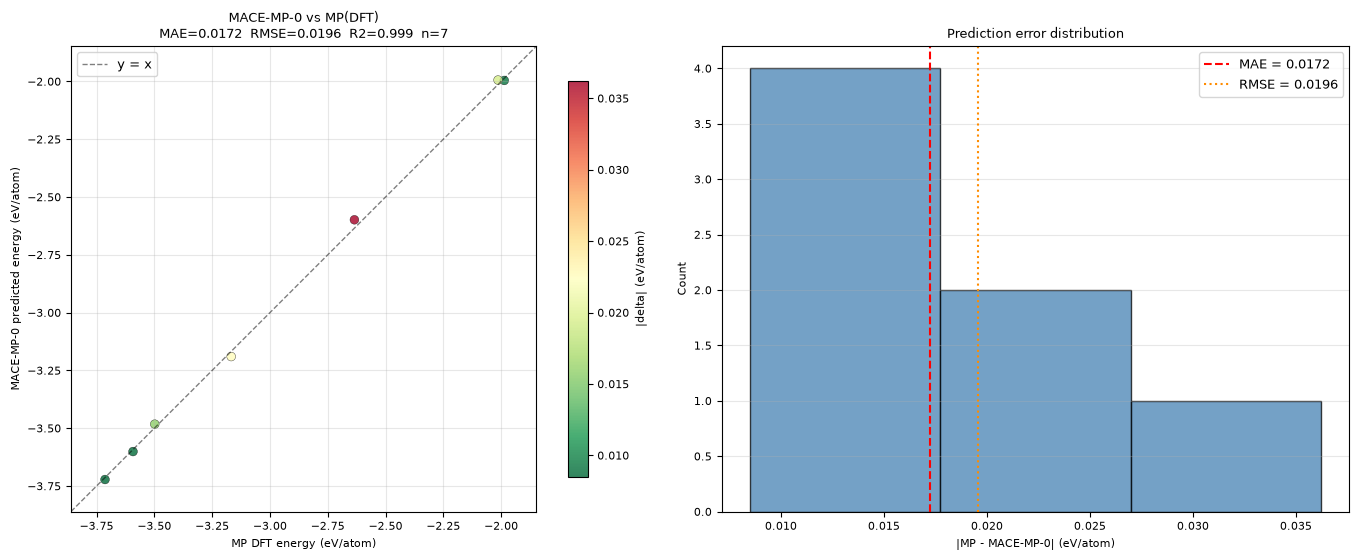

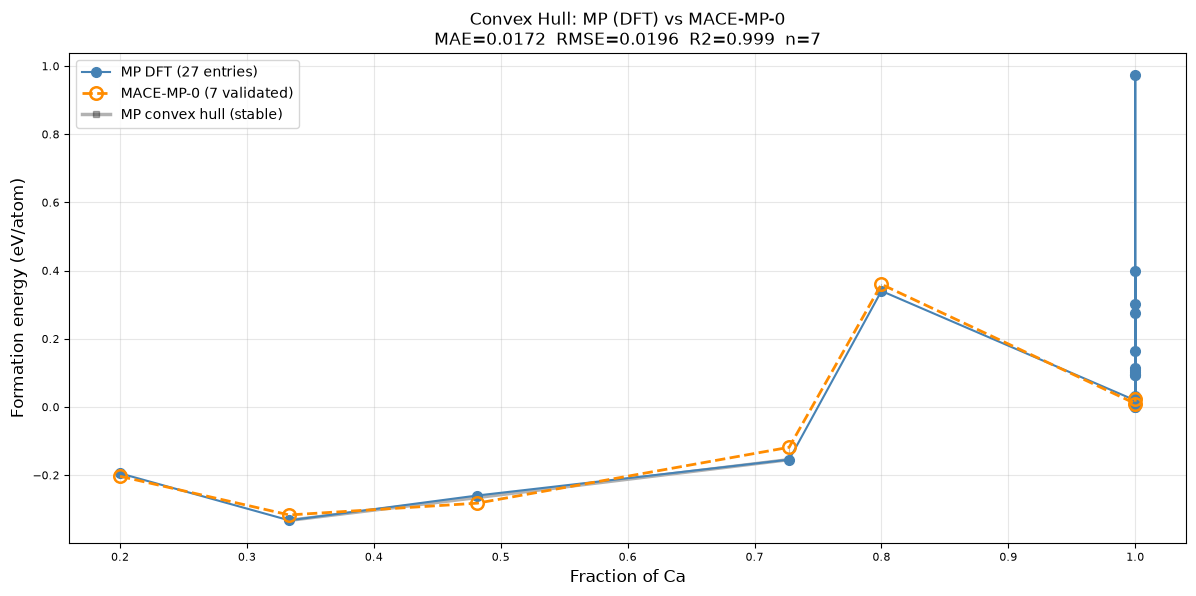


已保存: convex_hull_comparison_mace.png

验证完成。


In [6]:
if True:
    import warnings

    warnings.filterwarnings("ignore")

    try:
        from mace.calculators import mace_mp
        from ase.optimize import BFGS
        from ase import Atoms
        import torch

        _HAS_MACE = True
    except ImportError as e:
        _HAS_MACE = False
        print(f"❌ 缺少必要库: {e}")
        print("请安装: pip install mace-torch ase")

    if not _HAS_MACE:
        print("跳过验证。")
    else:
        print("=" * 60)
        print("MACE-MP-0 vs MP(DFT) Validation")
        print("=" * 60)

        _device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"\n[1/3] 加载 MACE-MP-0 模型 (设备: {_device})...")

        # ============================================================
        # ★★★ 在这里修改您的模型文件路径 ★★★
        # ============================================================
        # 方式1：直接使用模型名称（自动下载，需要网络通畅）
        # model_path = "MACE-MP-0"   # 或者 "medium", "small", "large"

        # 方式2：使用本地文件（推荐，避免下载问题）
        # 请将下载的 .model 文件放在笔记本同级目录，然后取消注释并修改文件名
        model_path = "2023-12-03-mace-128-L1_epoch-199.model"  # 修改为您的实际文件名
        # ============================================================

        try:
            calculator = mace_mp(
                model=model_path, device=_device, default_dtype="float32"
            )
            print("      模型加载完成")
        except Exception as e:
            print(f"      ❌ 加载失败: {e}")
            raise

        print("\n[2/3] 使用 MACE-MP-0 弛豫 MP 结构...")

        candidates = [
            e
            for e in entries
            if hasattr(e, "structure") and e.structure.num_sites <= MAX_VALIDATE_SITES
        ]

        seen = set()
        validate_entries = []
        for e in candidates:
            rf = e.composition.reduced_formula
            if rf not in seen:
                seen.add(rf)
                validate_entries.append(e)

        if MAX_VALIDATE_ENTRIES is not None:
            validate_entries = validate_entries[:MAX_VALIDATE_ENTRIES]

        print(f"      验证 {len(validate_entries)} 个条目")

        comparison = []
        for i, entry in enumerate(validate_entries):
            struct = entry.structure
            n = struct.num_sites
            mp_epa = entry.energy / n
            try:
                atoms = struct.to_ase_atoms()
                atoms.calc = calculator
                opt = BFGS(atoms, trajectory=None, logfile=None)
                opt.run(fmax=M3G_FMAX, steps=200)
                mace_epa = atoms.get_potential_energy() / n
                delta = abs(mace_epa - mp_epa)
                comparison.append(
                    dict(
                        formula=struct.formula,
                        entry_id=str(getattr(entry, "entry_id", "N/A")),
                        n_sites=n,
                        mp=mp_epa,
                        mace=mace_epa,
                        delta=delta,
                    )
                )
                print(
                    f"      [{i + 1}/{len(validate_entries)}] {struct.formula:20s}  "
                    f"MP={mp_epa:+.4f}  MACE={mace_epa:+.4f}  d={delta:.4f}"
                )
            except Exception as ex:
                print(
                    f"      [{i + 1}/{len(validate_entries)}] {struct.formula:20s}  FAIL: {ex}"
                )

        n_ok = len(comparison)
        print(f"\n      成功: {n_ok}/{len(validate_entries)}")

        if n_ok < 2:
            print("\n有效数据点太少，跳过绘图。")
        else:
            print("\n[3/3] 绘制对比图及统计指标...")

            import numpy as np

            mp_arr = np.array([d["mp"] for d in comparison])
            mace_arr = np.array([d["mace"] for d in comparison])
            delta_arr = np.array([d["delta"] for d in comparison])

            mae = np.mean(delta_arr)
            rmse = np.sqrt(np.mean(delta_arr**2))
            max_err = np.max(delta_arr)
            ss_res = np.sum((mp_arr - mace_arr) ** 2)
            ss_tot = np.sum((mp_arr - np.mean(mp_arr)) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 1e-12 else float("nan")

            print(
                f"  n={n_ok}  MAE={mae:.4f}  RMSE={rmse:.4f}  max={max_err:.4f}  R2={r2:.4f}"
            )

            print(
                f"\n{'entry_id':<30s} {'formula':<18s} {'MP':>10s} {'MACE-MP-0':>10s} {'|d|':>8s}"
            )
            print("-" * 80)
            for d in comparison:
                print(
                    f"{d['entry_id']:<30s} {d['formula']:<18s} "
                    f"{d['mp']:>10.4f} {d['mace']:>10.4f} {d['delta']:>8.4f}"
                )

            import matplotlib.pyplot as plt

            fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

            ax = axes[0]
            all_vals = np.concatenate([mp_arr, mace_arr])
            vmin, vmax = all_vals.min(), all_vals.max()
            pad = max((vmax - vmin) * 0.08, 0.1)
            vmin -= pad
            vmax += pad

            sc = ax.scatter(
                mp_arr,
                mace_arr,
                c=delta_arr,
                cmap="RdYlGn_r",
                s=40,
                edgecolors="k",
                linewidth=0.3,
                alpha=0.8,
            )
            ax.plot([vmin, vmax], [vmin, vmax], "k--", lw=1, alpha=0.5, label="y = x")
            ax.set_xlabel("MP DFT energy (eV/atom)")
            ax.set_ylabel("MACE-MP-0 predicted energy (eV/atom)")
            ax.set_title(
                f"MACE-MP-0 vs MP(DFT)\nMAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.3f}  n={n_ok}"
            )
            ax.legend(fontsize=9)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.set_aspect("equal")
            ax.grid(True, alpha=0.3)
            cbar = fig.colorbar(sc, ax=ax, shrink=0.85)
            cbar.set_label("|delta| (eV/atom)")

            ax2 = axes[1]
            ax2.hist(
                delta_arr,
                bins=min(20, n_ok // 2),
                edgecolor="k",
                color="steelblue",
                alpha=0.75,
            )
            ax2.axvline(mae, color="red", ls="--", lw=1.5, label=f"MAE = {mae:.4f}")
            ax2.axvline(
                rmse, color="darkorange", ls=":", lw=1.5, label=f"RMSE = {rmse:.4f}"
            )
            ax2.set_xlabel("|MP - MACE-MP-0| (eV/atom)")
            ax2.set_ylabel("Count")
            ax2.set_title("Prediction error distribution")
            ax2.legend(fontsize=9)
            ax2.grid(True, alpha=0.3, axis="y")

            plt.tight_layout()
            plt.show()

            # --- 凸包对比图 ---
            from pymatgen.analysis.phase_diagram import PhaseDiagram, PDEntry
            from pymatgen.core import Composition

            entries_with_struct = [e for e in entries if hasattr(e, "structure")]
            pd_mp = PhaseDiagram(
                [PDEntry(e.composition, e.energy) for e in entries_with_struct]
            )

            def _frac(comp):
                els = sorted(comp.keys())
                if len(els) <= 1:
                    return 1.0
                total = sum(comp.values())
                return comp.get(els[0], 0) / total

            mp_pts = []
            for e in entries_with_struct:
                fe = pd_mp.get_form_energy_per_atom(PDEntry(e.composition, e.energy))
                if fe is not None:
                    mp_pts.append((_frac(e.composition), fe, e.structure.formula))
            mp_pts.sort(key=lambda x: x[0])

            mace_pts = []
            mace_map = {d["formula"]: d["mace"] * d["n_sites"] for d in comparison}
            for d in comparison:
                comp = Composition(d["formula"])
                fe = pd_mp.get_form_energy_per_atom(
                    PDEntry(comp, mace_map[d["formula"]])
                )
                if fe is not None:
                    mace_pts.append((_frac(comp), fe, d["formula"]))
            mace_pts.sort(key=lambda x: x[0])

            stable = []
            for e in pd_mp.stable_entries:
                if len(e.composition) >= 2:
                    fe = pd_mp.get_form_energy_per_atom(e)
                    if fe is not None:
                        stable.append((_frac(e.composition), fe, e.composition.formula))
            stable.sort(key=lambda x: x[0])

            fig3, ax3 = plt.subplots(figsize=(12, 6))

            ax3.plot(
                [p[0] for p in mp_pts],
                [p[1] for p in mp_pts],
                "o-",
                color="steelblue",
                lw=1.5,
                ms=7,
                label=f"MP DFT ({len(mp_pts)} entries)",
            )

            ax3.plot(
                [p[0] for p in mace_pts],
                [p[1] for p in mace_pts],
                "o--",
                color="darkorange",
                lw=2,
                ms=9,
                markerfacecolor="none",
                markeredgewidth=1.8,
                label=f"MACE-MP-0 ({len(mace_pts)} validated)",
            )

            mp_lookup = {p[2]: p for p in mp_pts}
            for p in mace_pts:
                if p[2] in mp_lookup:
                    mp_p = mp_lookup[p[2]]
                    ax3.plot(
                        [p[0], p[0]],
                        [mp_p[1], p[1]],
                        color="gray",
                        lw=0.8,
                        alpha=0.5,
                        zorder=0,
                    )

            if len(stable) >= 2:
                ax3.plot(
                    [p[0] for p in stable],
                    [p[1] for p in stable],
                    "s-",
                    color="black",
                    lw=2.5,
                    ms=4,
                    alpha=0.3,
                    label="MP convex hull (stable)",
                    zorder=0,
                )

            ax3.set_xlabel(
                f"Fraction of {sorted(Composition(mp_pts[0][2]).keys())[0]}",
                fontsize=12,
            )
            ax3.set_ylabel("Formation energy (eV/atom)", fontsize=12)
            ax3.set_title(
                f"Convex Hull: MP (DFT) vs MACE-MP-0\n"
                f"MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.3f}  n={n_ok}",
                fontsize=12,
            )
            ax3.legend(fontsize=10, loc="upper left")
            ax3.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig("convex_hull_comparison_mace.png", dpi=150, bbox_inches="tight")
            plt.show()
            print("\n已保存: convex_hull_comparison_mace.png")

            print("\n验证完成。")
